In [2]:
#%pip install pandas matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [3]:
df = pd.read_csv('../data/processed/BankChurners_clean.csv')
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Avg_Trans_Amt,Activity_Segment,Revolving_Use
0,0,45,0,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,27.238095,Low,1
1,0,49,1,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,39.121212,Low,1
2,0,51,0,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,94.350000,Low,0
3,0,40,1,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,58.550000,Low,1
4,0,40,0,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,29.142857,Low,0


### Para construir un perfil de cliente que cancela su tarjeta de crédito vamos a seguir una estructura ordenada

### 1. En primer lugar calcularemos la tasa de churn para tenerla como punto de referencia

In [4]:
df['Attrition_Flag'].value_counts(normalize=True) * 100

Attrition_Flag
0    83.934038
1    16.065962
Name: proportion, dtype: float64

### Este es el número de referencia que usaremos durante todo el EDA: cualquier subgrupo que se aleje claramente de este 16% (por arriba o por abajo) será una pista relevante para el perfil que buscamos. También conviene tenerlo en cuenta para otra cosa: con un desbalance de clases de más o menos 84/16, cualquier media o proporción que calculemos sin segmentar estará dominada por el grupo mayoritario, por eso todo el resto del EDA se basa en comparar grupos (groupby por Attrition_Flag), nunca en mirar el dataset completo de forma agregada

### 2. Continuamos con el perfil demográfico

### 2.1 Edad

In [5]:
df.groupby('Attrition_Flag')['Customer_Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition_Flag,,,,,,,,
0,8500.0,46.262118,8.081157,26.0,41.0,46.0,52.0,73.0
1,1627.0,46.659496,7.665652,26.0,41.0,47.0,52.0,68.0


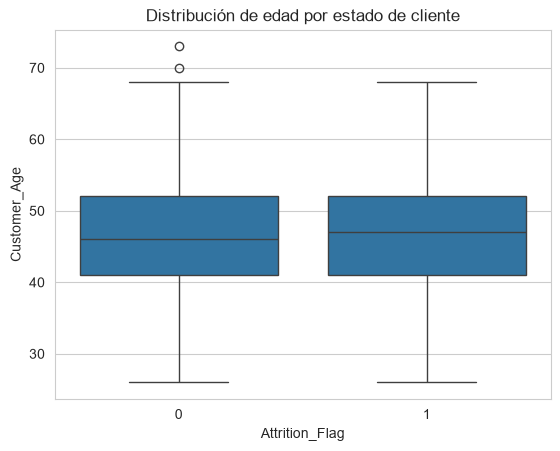

In [6]:
sns.boxplot(data=df, x='Attrition_Flag', y='Customer_Age')
plt.title('Distribución de edad por estado de cliente')
plt.show()

### Mdias prácticamente idénticas (46.26 vs 46.66 años), misma mediana casi (46 vs 47), mismos cuartiles. El boxplot lo confirma visualmente: la edad no diferencia al cliente que cancela

### 2.2 Género

In [7]:
pd.crosstab(df['Gender'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Gender,,
0,85.384777,14.615223
1,82.642777,17.357223


### 14.6% de churn en hombres vs 17.4% en mujeres. Hay una diferencia de más o menos 2.7 puntos, ligeramente por encima de la base (16.07%) en mujeres y por debajo en hombres, pero es un efecto modesto: no constituye un perfil claro por sí solo

### 2.3 Dependientes, educación, estado civil e ingresos

In [8]:
pd.crosstab(df['Dependent_count'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Dependent_count,,
0,85.066372,14.933628
1,85.364527,14.635473
2,84.293785,15.706215
3,82.357247,17.642753
4,83.481576,16.518424
5,84.905660,15.094340


### Todas las categorías oscilan entre 14.6% y 17.6%, sin un patrón creciente o decreciente claro con el número de hijos/dependientes. Sin relación aparente

In [9]:
pd.crosstab(df['Education_Level'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Education_Level,,
College,84.797631,15.202369
Doctorate,78.935698,21.064302
Graduate,84.430946,15.569054
High School,84.798808,15.201192
Post-Graduate,82.170543,17.829457
Uneducated,84.061870,15.938130
Unknown,83.146807,16.853193


### La mayoría de categorías rondan 15-16%, muy cerca de la base. Hay dos que destacan algo: Doctorate (21.06%) y Post-Graduate (17.83%) están por encima. Conviene comprobar el tamaño de Doctorate, porque si es un grupo pequeño, ese porcentaje puede ser ruido estadístico, no una señal real. Comprobamos su tamaño:

In [10]:
df['Education_Level'].value_counts()

Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64

### Confirmado. Doctorate representa solo 451 clientes (4.5% del dataset), el grupo más pequeño de las 7 categorías, junto con Post-Graduate (516, también el segundo más pequeño). Con tamaños de muestra tan reducidos, una diferencia de 21% vs 16% de base puede deberse perfectamente a variabilidad aleatoria, no a un patrón real (con más o menos 451 casos y 16% de tasa esperada, el margen de error de la proporción es considerable)

In [11]:
pd.crosstab(df['Marital_Status'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Marital_Status,,
Divorced,83.823529,16.176471
Married,84.873053,15.126947
Single,83.058585,16.941415
Unknown,82.777036,17.222964


### Rango estrecho (15.1% - 17.2%), sin patrón destacable. Single y Unknown ligeramente por encima de la base, Married ligeramente por debajo, pero diferencias pequeñas

In [12]:
pd.crosstab(df['Income_Category'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Income_Category,,
$120K +,82.668501,17.331499
$40K - $60K,84.860335,15.139665
$60K - $80K,86.519258,13.480742
$80K - $120K,84.234528,15.765472
Less than $40K,82.813816,17.186184
Unknown,83.183453,16.816547


### Rango similarmente estrecho (13.5% - 17.3%). Curiosamente, $120K + (17.3%) y Less than $40K (17.2%), los dos extremos de la escala de ingresos, tienen churn algo más alto que las categorías intermedias. Podría sugerir un patrón en forma de "U" (tanto rentas bajas como muy altas cancelan algo más), pero las diferencias son pequeñas (3-4 puntos) para considerarlo concluyente sin más evidencia

### Ninguna variable demográfica aporta una señal sólida y fiable sobre el churn. Las pequeñas desviaciones que vemos (Doctorate, género, ingresos extremos) son sutiles y, en al menos un caso, explicables por tamaño de muestra pequeño. No constituyen un perfil demográfico identificable

### 3. Vamos ahora a la vinculación del cliente con el banco

### 3.1 Antigüedad

In [13]:
df.groupby('Attrition_Flag')['Months_on_book'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition_Flag,,,,,,,,
0,8500.0,35.880588,8.021810,13.0,31.0,36.0,40.0,56.0
1,1627.0,36.178242,7.796548,13.0,32.0,36.0,40.0,56.0


### Prácticamente sin diferencia (35.88 vs 36.18 meses). Igual que pasó con la edad, la antigüedad no predice churn (un cliente nuevo no cancela más que uno veterano). Lo demográfico/temporal puro no discrimina

### 3.2. Número de productos contratados

In [14]:
pd.crosstab(df['Total_Relationship_Count'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Total_Relationship_Count,,
1,74.395604,25.604396
2,72.164119,27.835881
3,82.646421,17.353579
4,88.232218,11.767782
5,87.995769,12.004231
6,89.496249,10.503751


### Aquí aparece un patrón claro y monótono. Con 1 producto, el churn es 25.6%; con 2 productos, 27.8% (el pico); a partir de ahí cae de forma consistente: 17.4% (3), 11.8% (4), 12.0% (5), 10.5% (6). La diferencia entre el extremo bajo (más o menos 26-28%) y el alto (más o menos 10-12%) es de más de 2.5x. Esto confirma la hipótesis de vinculación: cuantos más productos tiene el cliente con el banco, menos probable es que cancele la tarjeta. Es uno de los hallazgos más sólidos hasta ahora

### 3.3. Meses de inactividad en los últimos 12

In [15]:
pd.crosstab(df['Months_Inactive_12_mon'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Months_Inactive_12_mon,,
0,48.275862,51.724138
1,95.521720,4.478280
2,84.613041,15.386959
3,78.523141,21.476859
4,70.114943,29.885057
5,82.022472,17.977528
6,84.677419,15.322581


### Patrón más complejo, con un detalle muy llamativo: el grupo 0 (sin ningún mes inactivo) tiene 51.7% de churn. Esto puede parecer contraintuitivo (¿el cliente más activo es el que más cancela?), pero hay una explicación lógica de negocio: probablemente sean clientes que cancelan la tarjeta poco después de usarla intensamente (cierre de cuenta a mitad de ciclo, sin pasar por un periodo de inactividad previo), no tienen tiempo de "enfriarse" antes de irse. Conviene verificar el tamaño de ese grupo 0, porque si es pequeño, igual que con Doctorate, hay que matizar su peso:

In [16]:
df['Months_Inactive_12_mon'].value_counts()

Months_Inactive_12_mon
3    3846
2    3282
1    2233
4     435
5     178
6     124
0      29
Name: count, dtype: int64

### Confirmado: el grupo Months_Inactive_12_mon = 0 tiene solo 29 clientes (0.29% del dataset), una muestra extremadamente pequeña. El 51.7% de churn calculado sobre ese grupo equivale a más o menos 15 clientes cancelados de 29 totales. Con un tamaño tan reducido, ese porcentaje tiene un margen de error enorme y no se puede considerar un patrón fiable, sino una posible casualidad estadística (o, como mucho, una pista a explorar con curiosidad, nunca como conclusión del perfil)

### El núcleo real de la variable está en las categorías 1, 2, 3, 4 (que concentran el 97% de los clientes: 2233, 3282, 3846, 435), y ahí sí el patrón es interpretable y fiable: el churn mínimo está en 1 mes inactivo (4.5%) y crece de forma consistente hasta 4 meses (29.9%). Las categorías 5 y 6 (178 y 124 casos) son más pequeñas pero todavía razonablemente robustas, y muestran cierta irregularidad (17.98% y 15.32%, ambas por debajo del pico de 4 meses), posiblemente porque ahí empiezan a mezclarse perfiles distintos (clientes inactivos de forma crónica pero estables, frente a los que cancelan)

### Número de contactos con el banco en los últimos 12 meses

In [17]:
pd.crosstab(df['Contacts_Count_12_mon'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Contacts_Count_12_mon,,
0,98.245614,1.754386
1,92.795197,7.204803
2,87.511621,12.488379
3,79.852071,20.147929
4,77.370690,22.629310
5,66.477273,33.522727
6,0.000000,100.000000


### El patrón más limpio y dramático de los cuatro. Crece de forma perfectamente monótona: 1.8% (0 contactos), 7.2%, 12.5%, 20.1%, 22.6%, 33.5%, 100% (6 contactos). El caso de 6 contactos con 100% de churn es extremo — todos los clientes que contactaron 6 veces con el banco en 12 meses acabaron cancelando. Igual que antes, verificamos el tamaño de ese grupo:

In [18]:
df['Contacts_Count_12_mon'].value_counts()

Contacts_Count_12_mon
3    3380
2    3227
1    1499
4    1392
0     399
5     176
6      54
Name: count, dtype: int64

### A diferencia del caso anterior, aquí sí podemos considerar el extremo como parte del patrón real, no como ruido. Y el resto de la tabla lo refuerza: el patrón es monótono y consistente en todas las categorías (0 a 6, sin excepciones ni irregularidades), algo que no ocurría en Months_Inactive. Esto convierte a Contacts_Count_12_mon en uno de los predictores más limpios y fiables encontrados hasta ahora: a mayor número de contactos con el banco en los últimos 12 meses, mayor probabilidad de cancelación, de forma prácticamente lineal.

### El cliente que cancela tiende a tener pocos productos contratados, cierta inactividad reciente, y sobre todo, un historial de múltiples contactos con el servicio del banco (lo cual sugiere fricciones o insatisfacción no resuelta antes del abandono). Este último punto es probablemente el hallazgo más accionable de todo el EDA hasta ahora: el banco tiene una señal de alerta temprana clara y monitorizable

### 4. Comportamiento del crédito

### 4.1 Límite del crédito

In [19]:
df.groupby('Attrition_Flag')['Credit_Limit'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition_Flag,,,,,,,,
0,8500.0,8726.877518,9084.969807,1438.3,2602.0,4643.5,11252.75,34516.0
1,1627.0,8136.039459,9095.334105,1438.3,2114.0,4178.0,9933.50,34516.0


### Apenas hay diferencia (8727 vs 8136), una variación pequeña. No es un predictor relevante por sí solo

### 4.2 Saldo revolving (deuda arrastrada)

In [20]:
df.groupby('Attrition_Flag')['Total_Revolving_Bal'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition_Flag,,,,,,,,
0,8500.0,1256.604118,757.745354,0.0,800.0,1364.0,1807.0,2517.0
1,1627.0,672.822987,921.385582,0.0,0.0,0.0,1303.5,2517.0


### Aquí sí hay una diferencia notable: los clientes que cancelan tienen una mediana de 0 (frente a 1364 en los que se quedan), y su media es mucho menor (672.8 vs 1256.6). Es decir, el cliente que cancela tiende a NO tener deuda revolving

### 4.3 Ratio de utilización

In [21]:
df.groupby('Attrition_Flag')['Avg_Utilization_Ratio'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition_Flag,,,,,,,,
0,8500.0,0.296412,0.272568,0.0,0.055,0.211,0.52925,0.994
1,1627.0,0.162475,0.264458,0.0,0.000,0.000,0.23100,0.999


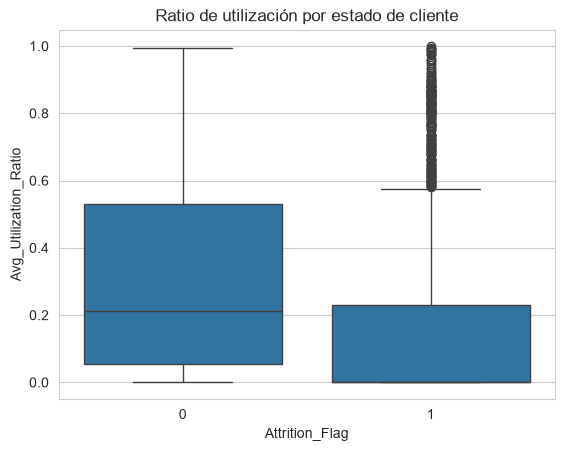

In [24]:
sns.boxplot(data=df, x='Attrition_Flag', y='Avg_Utilization_Ratio')
plt.title('Ratio de utilización por estado de cliente')
plt.show()

### Mismo patrón, reforzado por el boxplot: la mediana del grupo que cancela es 0, mientras que el grupo que se queda tiene mediana 0.211 y un rango intercuartílico mucho más amplio (0.055 a 0.529). El boxplot muestra además algo muy revelador: el grupo que cancela (1) tiene una enorme cantidad de outliers superiores, es decir, dentro de los que cancelan hay dos subgrupos: una mayoría aplastante con utilización 0 (o casi) y un grupo minoritario con utilización muy alta, casi sin término medio

###  El patrón mayoritario de churn es el cliente de bajo uso/vinculación, pero existe un segmento minoritario (visible en los outliers del boxplot) con utilización muy alta que merece mención aparte. Vamos a cuantificarlo:

In [25]:
alta_utilizacion = df[df['Avg_Utilization_Ratio'] > 0.57]  # aprox. donde empiezan los outliers en el boxplot
alta_utilizacion['Attrition_Flag'].value_counts(normalize=True) * 100

Attrition_Flag
0    90.341463
1     9.658537
Name: proportion, dtype: float64

### Este resultado es clave y termina de aclarar el panorama: dentro del grupo de alta utilización (>0.57), solo el 9.66% cancela, un porcentaje incluso por debajo de la tasa base (16.07%)

### 4.4 Uso de revolving

In [22]:
pd.crosstab(df['Revolving_Use'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Revolving_Use,,
0,63.846154,36.153846
1,90.414000,9.586000


### Solo el 9.59% de los clientes que sí usan revolving cancelan, frente al 36.15% de los que no lo usan. La diferencia es enorme: más de 3.7 veces más churn entre quienes no arrastran deuda

### El cliente que cancela la tarjeta es, predominantemente, uno que apenas la usa como instrumento de crédito (no genera saldo revolving, no acumula utilización). Esto encaja perfectamente con el perfil que teníamos en el bloque 3 (pocos productos, cierta inactividad): es un cliente con bajo compromiso global con el producto, no uno atrapado por deuda

### 5. Comportamiento transaccional

### 5.1 Importe total de transacciones

In [26]:
df.groupby('Attrition_Flag')['Total_Trans_Amt'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition_Flag,,,,,,,,
0,8500.0,4654.655882,3512.772635,816.0,2384.75,4100.0,4781.25,18484.0
1,1627.0,3095.025814,2308.227629,510.0,1903.50,2329.0,2772.00,10583.0


### Diferencia notable: media de 4655 (no cancela) vs 3095 (cancela), una caída de más o menos el 33%. El cliente que cancela gasta bastante menos en total

### 5.2 Número total de transacciones

In [27]:
df.groupby('Attrition_Flag')['Total_Trans_Ct'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition_Flag,,,,,,,,
0,8500.0,68.672588,22.919011,11.0,54.0,71.0,82.0,139.0
1,1627.0,44.933620,14.568429,10.0,37.0,43.0,51.0,94.0


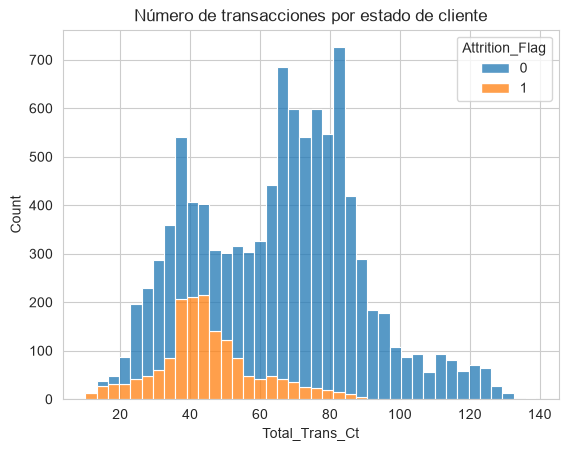

In [33]:
sns.histplot(data=df, x='Total_Trans_Ct', hue='Attrition_Flag', bins=40, multiple='stack')
plt.title('Número de transacciones por estado de cliente')
plt.show()

###  El hallazgo más potente del bloque: 68.67 transacciones de media en quien se queda vs 44.93 en quien cancela. La mediana confirma lo mismo (71 vs 43). El histograma lo ilustra perfectamente: el churn se concentra casi por completo en el primer pico (20-50 transacciones), y prácticamente desaparece a partir de 60-70, justo donde domina el segundo pico de la distribución general. Esto confirma que el churn se concentra en el grupo de baja actividad transaccional, no se distribuye uniformemente entre los dos picos

### 5.3  Importe medio por transacción

In [28]:
df.groupby('Attrition_Flag')['Avg_Trans_Amt'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition_Flag,,,,,,,,
0,8500.0,62.425055,26.189216,19.137931,47.873641,55.920809,65.118421,190.193182
1,1627.0,63.593125,27.487516,21.250000,46.179116,54.954545,68.220238,183.540000


### Aquí, en cambio, no hay diferencia (62.43 vs 63.59, prácticamente iguales). Esto es muy informativo en combinación con los dos puntos anteriores: el cliente que cancela no gasta menos por transacción individual (su ticket medio es igual), simplemente realiza muchas menos transacciones en total

### 5.4 Segmento de actividad

In [29]:
pd.crosstab(df['Activity_Segment'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Activity_Segment,,
High,99.866310,0.133690
Low,83.894871,16.105129
Medium,68.328841,31.671159


### El segmento High tiene 0.13% de churn (prácticamente nadie cancela), Low tiene 16.1% (justo la base), y Medium tiene 31.67% (el doble que la base). Aquí hay un matiz interesante a señalar: no es un patrón monótono donde más actividad siempre implica menos churn: es el grupo Medium el que más cancela, no el Low. Esto sugiere que el segmento High (clientes de uso muy intensivo, recordemos que esta categoría solo tenía 748 clientes) son los más fieles con diferencia, mientras que Medium podría representar un perfil de transición — clientes que estaban relativamente activos pero insuficientemente vinculados, posiblemente en proceso de desenganche antes de cancelar del todo

### Vamos a comprobar brevemente por qué Medium supera a Low en el churn

In [34]:
df.groupby('Activity_Segment')['Total_Trans_Ct'].describe()

,count,mean,std,min,25%,50%,75%,max
Activity_Segment,,,,,,,,
High,748.0,110.288770,10.788562,75.0,102.0,111.0,119.0,139.0
Low,8637.0,59.336112,19.566176,10.0,42.0,63.0,76.0,103.0
Medium,742.0,83.345013,12.995467,40.0,74.0,85.0,93.0,122.0


### Medium no tiene menos transacciones que High de forma desproporcionada — de hecho mantiene un orden lógico y esperado (Low: 63 < Medium: 85 < High: 111), sin ningún salto raro. No hay "tickets grandes pero pocas transacciones" escondidos en Medium

### High tiene el rango más estrecho y compacto de todos (std 10.79, rango 75-139), mientras que Medium tiene una dispersión proporcionalmente mayor (std 12.99 sobre una media más baja) y, sobre todo, solo 748 clientes en High con churn casi nulo (0.13%, prácticamente 1 cliente) frente a 742 en Medium con 31.67% (más o menos 235 clientes)

### La explicación más plausible es que High representa un perfil de cliente genuinamente distinto y excepcionalmente fiel (posiblemente clientes de uso profesional/intensivo, muy vinculados al producto), mientras que Medium no es tanto "un segmento problemático en sí mismo" sino que simplemente no goza de la protección casi total que sí tiene High, su tasa de churn (31.67%) es más alta que la de Low solo porque High "roba" de forma desproporcionada los clientes más leales del extremo de actividad alta, dejando que en Medium se concentre una mezcla de clientes en transición sin ese blindaje

### Vamos a comprobar si Medium tiene mayor presencia de los otros indicadores de bajo compromiso que ya conocemos (Total_Relationship_Count, Contacts_Count_12_mon) comparado con High:

In [35]:
df.groupby('Activity_Segment')[['Total_Relationship_Count', 'Contacts_Count_12_mon', 'Months_Inactive_12_mon']].mean()

,Total_Relationship_Count,Contacts_Count_12_mon,Months_Inactive_12_mon
Activity_Segment,,,
High,2.360963,2.225936,2.215241
Low,4.074679,2.488827,2.354058
Medium,2.225067,2.296496,2.318059


### Medium y High comparten baja vinculación en productos (más o menos 2.2-2.4), pero se diferencian radicalmente en volumen transaccional (83 vs 110). Es precisamente ese diferencial de actividad, sin el colchón de vinculación con otros productos, lo que parece marcar la diferencia: High compensa su baja vinculación con un uso muy intensivo de la tarjeta (110 transacciones es mucho), mientras que Medium no alcanza ese nivel de uso y, sin el colchón de otros productos tampoco, po lo tanto cae en zona de mayor riesgo (31.67%)

### 5.5 Cambio de importe Q4 vs Q1

In [30]:
df.groupby('Attrition_Flag')['Total_Amt_Chng_Q4_Q1'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition_Flag,,,,,,,,
0,8500.0,0.772510,0.217783,0.256,0.6430,0.743,0.860,3.397
1,1627.0,0.694277,0.214924,0.000,0.5445,0.701,0.856,1.492


### 5.6 Cambio de número de transacciones Q4 vs Q1

In [31]:
df.groupby('Attrition_Flag')['Total_Ct_Chng_Q4_Q1'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition_Flag,,,,,,,,
0,8500.0,0.742434,0.228054,0.028,0.617,0.721,0.833,3.714
1,1627.0,0.554386,0.226854,0.000,0.400,0.531,0.692,2.500


### Ambos confirman que el grupo que cancela tiene ratios más bajos (0.694 vs 0.772 en importe; 0.554 vs 0.742 en conteo), es decir, reduce su actividad de Q1 a Q4 de forma más marcada que el cliente que se queda. El efecto es más pronunciado en Total_Ct_Chng_Q4_Q1

### El comportamiento transaccional es, con diferencia, el área más predictiva del churn. El perfil que emerge es nítido: un cliente que usa la tarjeta con poca frecuencia (no necesariamente con tickets bajos) y que además muestra una caída de actividad hacia el final del año. Esto refuerza y cuantifica el "bajo compromiso" que veníamos detectando en los bloques 3 y 4, aquí encontramos la métrica más directa y accionable de todas: el número de transacciones

### 6. Tipo de tarjeta

In [36]:
pd.crosstab(df['Card_Category'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Card_Category,,
Blue,83.902077,16.097923
Gold,81.896552,18.103448
Platinum,75.000000,25.000000
Silver,85.225225,14.774775


In [37]:
df['Card_Category'].value_counts()

Card_Category
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64

### Card_Category no aporta señal relevante al perfil de churn por dos razones combinadas: la concentración masiva en Blue hace que cualquier diferencia entre categorías sea difícil de separar del ruido, y los grupos premium (Gold, Platinum) son demasiado pequeños para ser estadísticamente robustos

### Vamos a generar ahora la matriz de correlaciones. Excluiremos de la misma Avg_Open_To_Buy de la visualización ya que es matemáticamente redundante con Credit_Limit y Total_Revolving_Bal y Revolving_Use ya que es una versión binaria derivada directamente de Total_Revolving_Bal (si saldo > 0), así que su correlación tampoco añade nada independiente

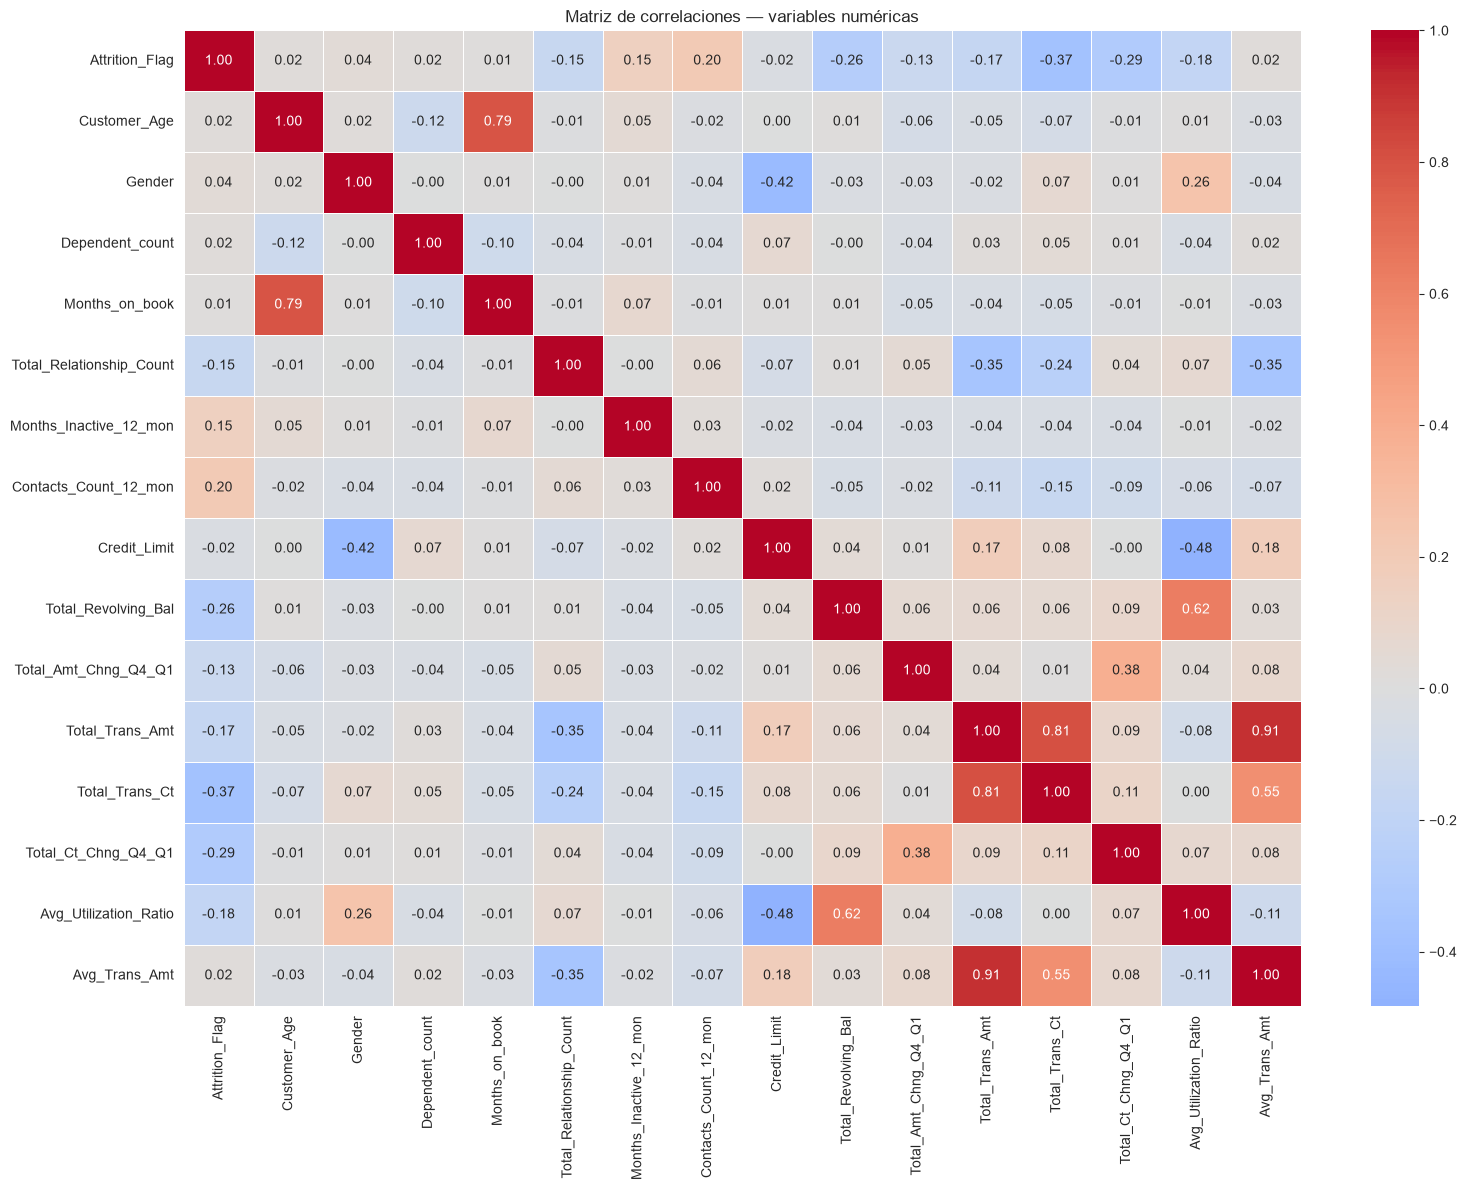

In [39]:
excluir = ['Avg_Open_To_Buy', 'Revolving_Use']
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numericas_filtradas = [col for col in numericas if col not in excluir]

plt.figure(figsize=(16, 12))
sns.heatmap(
    df[numericas_filtradas].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Matriz de correlaciones — variables numéricas')
plt.tight_layout()
plt.show()

### No hay ninguna sorpresa que contradiga los bloques anteriores, pero sí dos confirmaciones importantes: Total_Trans_Ct es formalmente la variable con mayor correlación con churn (-0.37), y Total_Ct_Chng_Q4_Q1 es la segunda (-0.29), justo lo que habíamos anticipado. La matriz también revela que Avg_Trans_Amt es redundante con Total_Trans_Amt (0.91)

### Ahora mostraremos un resumen univariante extraido de la investigación previa en el documento preprocessing.ipynb por no redundar en lo ya comprobado

### Variables numéricas continuas

Lo que ya sabemos de cada una, extraído del análisis de outliers:

| Variable | Distribución | Skew | Notas |
|---|---|---|---|
| Customer_Age | Normal, unimodal, simétrica | ≈0 | La que "mejor se comporta" del dataset |
| Months_on_book | Pico artificial en 36 meses (24.3% del dataset) | -0.11 | Posible artefacto de generación sintética aunque se concluye que no es así |
| Credit_Limit | Asimétrica derecha, cola larga | 1.67 | Clientes premium en la cola |
| Avg_Open_To_Buy | Ídem, correlacionada con Credit_Limit | 1.66 | Redundante con Credit_Limit y Total_Revolving_Bal |
| Total_Revolving_Bal | Bimodal: pico en 0 y distribución en resto | -0.15 | Pico en 0 = clientes sin deuda revolving (legítimo) |
| Total_Trans_Amt | Trimodal: 3 grupos separados por huecos reales | 2.04 | Segmentación real, no outliers |
| Total_Trans_Ct | Bimodal: dos picos (~40 y ~80 transacciones) | 0.15 | Dos perfiles de uso claramente distintos |
| Total_Amt_Chng_Q4_Q1 | Unimodal, cola derecha larga | 1.73 | Núcleo compacto (0.63-0.86), extremos legítimos |
| Total_Ct_Chng_Q4_Q1 | Ídem | 2.06 | Mismo patrón |
| Avg_Utilization_Ratio | Sin outliers, rango 0-10.72 | - | Matemáticamente acotada |
| Avg_Trans_Amt | Asimétrica derecha | - | Alta correlación con Total_Trans_Amt (0.91) |

### Variables discretas acotadas

Excluidas del análisis de outliers por definición — rango natural demasiado corto para que el concepto de "valor extremo" tenga sentido:

| Variable | Rango | Notas |
|---|---|---|
| Total_Relationship_Count | 1-6 | Sin outliers por diseño |
| Dependent_count | 0-5 | Sin outliers por diseño |
| Contacts_Count_12_mon | 0-6 | Sin outliers por diseño |
| Months_Inactive_12_mon | 0-6 | Sin outliers por diseño |

### Variables binarias

| Variable | Distribución | Notas |
|---|---|---|
| Attrition_Flag | 83.9% / 16.1% | Dataset desbalanceado |
| Gender | — | Sin relevancia para churn |
| Revolving_Use | 75.6% usa revolving / 24.4% no | Alta correlación con Total_Revolving_Bal |

### Variables categóricas

| Variable | Notas |
|---|---|
| Education_Level | Graduate mayoritaria (3128), Doctorate minoritaria (451) |
| Income_Category | Sin patrón claro con churn |
| Card_Category | Blue domina (9436/10127, 93.2%) |
| Marital_Status | Sin patrón claro con churn |
| Activity_Segment | Muy desbalanceada: Low 85.3%, Medium y High ~7.3% cada una |

### El dataset tiene una mezcla de distribuciones muy variadas: desde la única variable verdaderamente normal (Customer_Age) hasta distribuciones trimodales con huecos reales (Total_Trans_Amt), pasando por variables con picos que parecen artificiales (Months_on_book) y variables con concentración extrema en una categoría (Card_Category, Activity_Segment)

### 7. Perfil de cliente que cancela la tarjeta de crédito

### Vamos a construir el perfil ordenando los hallazgos de mayor a menor poder discriminante, basándonos en todo lo que hemos visto.

### Lo que NO define al cliente que cancela
### Antes de describir el perfil, es importante descartar explícitamente lo que no lo explica — porque es un hallazgo en sí mismo y evita narrativas falsas en el storytelling:

### Edad: prácticamente idéntica entre ambos grupos (46.26 vs 46.66 años).
### Género: diferencia de apenas 2.7 puntos porcentuales.
### Antigüedad con el banco: sin diferencia relevante.
### Número de dependientes: sin patrón.
### Nivel educativo e ingresos: diferencias marginales y no consistentes.
### Límite de crédito: sin diferencia relevante.
### Ticket medio por transacción: prácticamente idéntico (62.43 vs 63.59).

### Conclusión de este bloque negativo: el cliente que cancela no tiene un perfil demográfico diferencial. No es ni más joven ni más mayor, ni más rico ni más pobre, ni más ni menos educado. No es quién es, sino cómo se comporta con el producto.

### El perfil real: comportamiento, no demografía
### 1. Bajo uso transaccional — el predictor más fuerte (-0.37)
### El cliente que cancela realiza significativamente menos transacciones: mediana de 43 frente a 71 en clientes activos. No es que gaste menos por transacción (el ticket medio es igual), simplemente usa la tarjeta con mucha menos frecuencia. El histograma bimodal de Total_Trans_Ct lo ilustra perfectamente: el churn se concentra casi exclusivamente en el primer pico (20-50 transacciones), mientras que el segundo pico (60-100) es territorio de retención.
### 2. Caída de actividad hacia fin de año — segunda señal más fuerte (-0.29)
### El ratio Total_Ct_Chng_Q4_Q1 (mediana 0.531 en churners vs 0.721 en activos) revela que el cliente que cancela no solo usa poco la tarjeta, sino que reduce progresivamente su uso a lo largo del año — una señal de desenganche gradual que el banco podría detectar de forma temprana antes de que se produzca la cancelación efectiva.
### 3. Baja vinculación con el banco
### Con frecuencia tiene pocos productos contratados (1-2 vs 4-6 en los más fieles): tasa de churn del 25-28% con 1-2 productos frente al 10-12% con 4-6. La tarjeta es prácticamente su único punto de contacto con la entidad, sin el "colchón" de vinculación que ofrecen otros productos (cuentas, préstamos, seguros).
### 4. No usa el crédito revolving
### Solo el 9.6% de los clientes que sí arrastran deuda cancelan, frente al 36.2% de los que no la arrastran. El cliente que cancela tiende a tener saldo revolving 0 (mediana 0 vs 1364 en activos) y ratio de utilización prácticamente nulo (mediana 0.000 vs 0.211). Esto refuerza el perfil de bajo compromiso: no solo usa poco la tarjeta en transacciones, sino que tampoco la usa como instrumento de crédito.
### 5. Historial de contactos frecuentes con el banco
### La relación entre contactos y churn es la más limpia y monótona del análisis: de 1.8% de churn con 0 contactos hasta 100% con 6 contactos. El cliente que cancela ha contactado repetidamente con el banco — posiblemente intentando resolver problemas, negociar condiciones o simplemente como paso previo a la decisión de cancelar. Es la señal de alerta más accionable de todo el análisis.

### Retrato robot del cliente que cancela

### Cliente con 1-2 productos contratados con el banco, que usa la tarjeta de forma esporádica (menos de 50 transacciones anuales) y que no genera deuda revolving. A lo largo del año muestra una caída progresiva de actividad (especialmente en el número de transacciones de Q1 a Q4) y ha contactado con el banco en múltiples ocasiones antes de cancelar. No hay un perfil demográfico diferencial: puede tener cualquier edad, género, nivel educativo o renta.

### Implicación para el negocio
| Señal | Cuándo actuar |
|---|---|
| Caída en número de transacciones trimestre a trimestre | Detección temprana |
| Aumento de contactos con el banco (3+) | Intervención inmediata |
| Saldo revolving cayendo a 0 de forma sostenida | Señal de desvinculación del crédito |
| Solo 1-2 productos contratados | Oportunidad de cross-selling preventivo |